In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
import folium
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
pmkisan_url = "https://raw.githubusercontent.com/datameet/india-farmer-data/master/pm-kisan/pmkisan_statewise.csv"

try:
    pmkisan = pd.read_csv(pmkisan_url)
    print("✅ PM-KISAN data loaded")
    print(f"   Shape: {pmkisan.shape}")
    print(pmkisan.head())
except:
    print("⚠️  Remote file unavailable — we'll create structured sample data below")
    pmkisan = None

⚠️  Remote file unavailable — we'll create structured sample data below


In [4]:

data = {
    'state': [
        'Uttar Pradesh', 'Uttar Pradesh', 'Uttar Pradesh', 'Uttar Pradesh', 'Uttar Pradesh',
        'Bihar', 'Bihar', 'Bihar', 'Bihar', 'Bihar',
        'Madhya Pradesh', 'Madhya Pradesh', 'Madhya Pradesh', 'Madhya Pradesh',
        'Rajasthan', 'Rajasthan', 'Rajasthan', 'Rajasthan',
        'Maharashtra', 'Maharashtra', 'Maharashtra', 'Maharashtra',
        'West Bengal', 'West Bengal', 'West Bengal', 'West Bengal',
        'Odisha', 'Odisha', 'Odisha', 'Odisha',
        'Jharkhand', 'Jharkhand', 'Jharkhand',
        'Assam', 'Assam', 'Assam',
        'Karnataka', 'Karnataka', 'Karnataka',
        'Andhra Pradesh', 'Andhra Pradesh', 'Andhra Pradesh',
        'Tamil Nadu', 'Tamil Nadu', 'Tamil Nadu',
        'Gujarat', 'Gujarat', 'Gujarat',
        'Haryana', 'Haryana',
        'Punjab', 'Punjab',
    ],
    'district': [
        'Sitapur', 'Bahraich', 'Hardoi', 'Lakhimpur Kheri', 'Balrampur',
        'Madhubani', 'Sitamarhi', 'Araria', 'Darbhanga', 'Supaul',
        'Sheopur', 'Barwani', 'Dindori', 'Alirajpur',
        'Barmer', 'Jaisalmer', 'Sirohi', 'Dungarpur',
        'Nandurbar', 'Gadchiroli', 'Osmanabad', 'Washim',
        'Murshidabad', 'Malda', 'Purulia', 'Birbhum',
        'Malkangiri', 'Nabarangpur', 'Rayagada', 'Nuapada',
        'Pakur', 'Sahibganj', 'Garhwa',
        'Dhubri', 'Kokrajhar', 'Goalpara',
        'Yadgir', 'Raichur', 'Koppal',
        'Vizianagaram', 'Srikakulam', 'Kurnool',
        'Dharmapuri', 'Villupuram', 'Ariyalur',
        'Dahod', 'Panchmahal', 'Narmada',
        'Mewat', 'Sirsa',
        'Fazilka', 'Mansa',
    ],
    'agri_hh_000': [
        312, 287, 298, 276, 198,
        284, 312, 267, 298, 187,
        142, 167, 98, 87,
        198, 67, 112, 134,
        156, 89, 123, 98,
        287, 243, 178, 212,
        87, 112, 98, 76,
        98, 87, 112,
        187, 143, 98,
        112, 143, 98,
        134, 156, 187,
        98, 167, 87,
        112, 143, 67,
        87, 98,
        76, 89,
    ],
    'enrolled_000': [
        198, 156, 187, 189, 112,
        143, 143, 121, 156, 98,
        98, 102, 54, 43,
        134, 51, 78, 87,
        89, 43, 67, 56,
        187, 143, 98, 134,
        38, 52, 47, 31,
        43, 36, 54,
        98, 67, 43,
        78, 102, 71,
        112, 123, 143,
        67, 112, 54,
        89, 112, 51,
        54, 67,
        61, 72,
    ],
    'literacy_rate': [
        58.5, 49.3, 60.2, 61.4, 46.7,
        51.2, 48.7, 50.1, 53.4, 52.8,
        59.2, 48.3, 52.4, 44.2,
        55.0, 57.1, 60.2, 53.4,
        52.4, 44.7, 67.3, 68.9,
        63.8, 57.1, 64.8, 70.1,
        49.5, 46.7, 51.3, 50.2,
        47.2, 53.4, 55.8,
        53.4, 61.2, 64.7,
        58.5, 60.1, 67.4,
        58.9, 55.4, 67.8,
        72.3, 68.4, 71.2,
        70.1, 68.7, 64.3,
        56.3, 71.2,
        69.4, 63.8,
    ],
    'bank_access_pct': [
        52.3, 44.7, 55.6, 57.8, 41.2,
        58.9, 53.4, 49.8, 61.2, 55.3,
        62.4, 54.3, 48.7, 42.1,
        67.8, 71.2, 65.4, 58.9,
        58.7, 47.3, 69.8, 67.4,
        79.3, 71.2, 68.4, 74.5,
        52.4, 49.8, 53.7, 47.6,
        48.9, 51.2, 56.7,
        61.3, 58.7, 63.4,
        65.4, 69.8, 71.2,
        74.5, 71.8, 79.3,
        74.8, 71.3, 69.8,
        78.9, 82.3, 71.2,
        74.3, 82.1,
        86.7, 79.4,
    ],
    'women_hh_pct': [
        12.3, 11.8, 13.4, 14.2, 10.9,
        13.2, 12.7, 11.4, 14.8, 13.6,
        14.5, 13.2, 15.6, 16.7,
        10.2, 9.8, 11.3, 14.5,
        15.6, 18.9, 14.3, 13.7,
        23.4, 21.7, 22.8, 20.3,
        19.8, 21.3, 22.7, 20.1,
        18.9, 17.4, 16.8,
        14.7, 16.3, 15.8,
        16.4, 15.8, 14.9,
        16.2, 17.8, 15.3,
        18.7, 17.4, 16.8,
        15.3, 14.8, 16.7,
        13.4, 12.8,
        11.2, 12.7,
    ],
    'internet_per100': [
        18.4, 12.3, 16.7, 19.8, 10.2,
        14.5, 11.8, 10.4, 15.6, 13.2,
        22.3, 15.6, 12.4, 9.8,
        24.5, 28.9, 21.3, 18.7,
        19.8, 12.4, 23.4, 21.7,
        32.4, 27.8, 22.3, 28.9,
        14.3, 12.7, 15.6, 11.8,
        13.4, 12.8, 16.7,
        19.8, 22.4, 24.7,
        28.9, 31.2, 27.8,
        34.5, 31.8, 38.9,
        38.7, 34.3, 32.8,
        41.2, 38.9, 35.6,
        44.3, 52.1,
        48.7, 43.2,
    ],
}

df = pd.DataFrame(data)

df['uptake_gap_pct'] = round(
    100 * (1 - df['enrolled_000'] / df['agri_hh_000']), 1
)

df['coverage_rate_pct'] = round(
    100 * df['enrolled_000'] / df['agri_hh_000'], 1
)

df['missed_hh_000'] = round(df['agri_hh_000'] - df['enrolled_000'], 1)

print("✅ Dataset created successfully!")
print(f"   Districts: {len(df)}")
print(f"   States:    {df['state'].nunique()}")
print(f"\n── First look at the data ──")
print(df[['state','district','agri_hh_000','enrolled_000',
          'uptake_gap_pct','missed_hh_000']].head(10).to_string(index=False))

✅ Dataset created successfully!
   Districts: 52
   States:    15

── First look at the data ──
        state        district  agri_hh_000  enrolled_000  uptake_gap_pct  missed_hh_000
Uttar Pradesh         Sitapur          312           198            36.5            114
Uttar Pradesh        Bahraich          287           156            45.6            131
Uttar Pradesh          Hardoi          298           187            37.2            111
Uttar Pradesh Lakhimpur Kheri          276           189            31.5             87
Uttar Pradesh       Balrampur          198           112            43.4             86
        Bihar       Madhubani          284           143            49.6            141
        Bihar       Sitamarhi          312           143            54.2            169
        Bihar          Araria          267           121            54.7            146
        Bihar       Darbhanga          298           156            47.7            142
        Bihar          S

In [5]:
print("=" * 55)
print("  PM-KISAN UPTAKE GAP — SUMMARY STATISTICS")
print("=" * 55)

print(f"\n  Total districts analysed   : {len(df)}")
print(f"  Total states covered       : {df['state'].nunique()}")
print(f"  Total eligible HH (lakh)   : {df['agri_hh_000'].sum() / 100:.1f} lakh")
print(f"  Total enrolled HH (lakh)   : {df['enrolled_000'].sum() / 100:.1f} lakh")
print(f"  Total MISSED HH (lakh)     : {df['missed_hh_000'].sum() / 100:.1f} lakh")

avg_gap = df['uptake_gap_pct'].mean()
print(f"\n  Average uptake gap         : {avg_gap:.1f}%")
print(f"  Worst gap (district)       : {df['uptake_gap_pct'].max():.1f}% — {df.loc[df['uptake_gap_pct'].idxmax(), 'district']}, {df.loc[df['uptake_gap_pct'].idxmax(), 'state']}")
print(f"  Best coverage (district)   : {df['coverage_rate_pct'].max():.1f}% — {df.loc[df['coverage_rate_pct'].idxmax(), 'district']}, {df.loc[df['coverage_rate_pct'].idxmax(), 'state']}")

print(f"\n── Uptake gap by state (average) ──")
state_summary = (df.groupby('state')
                   .agg(avg_gap    = ('uptake_gap_pct',  'mean'),
                        total_missed= ('missed_hh_000',   'sum'),
                        districts   = ('district',        'count'))
                   .round(1)
                   .sort_values('avg_gap', ascending=False))
print(state_summary.to_string())

  PM-KISAN UPTAKE GAP — SUMMARY STATISTICS

  Total districts analysed   : 52
  Total states covered       : 15
  Total eligible HH (lakh)   : 80.6 lakh
  Total enrolled HH (lakh)   : 48.4 lakh
  Total MISSED HH (lakh)     : 32.2 lakh

  Average uptake gap         : 39.3%
  Worst gap (district)       : 59.2% — Nuapada, Odisha
  Best coverage (district)   : 83.6% — Vizianagaram, Andhra Pradesh

── Uptake gap by state (average) ──
                avg_gap  total_missed  districts
state                                           
Jharkhand          55.5           164          3
Odisha             55.3           205          4
Assam              52.3           220          3
Bihar              50.8           687          5
Maharashtra        45.8           211          4
Madhya Pradesh     41.4           197          4
West Bengal        39.4           358          4
Uttar Pradesh      38.8           529          5
Haryana            34.8            64          2
Tamil Nadu         34.1     

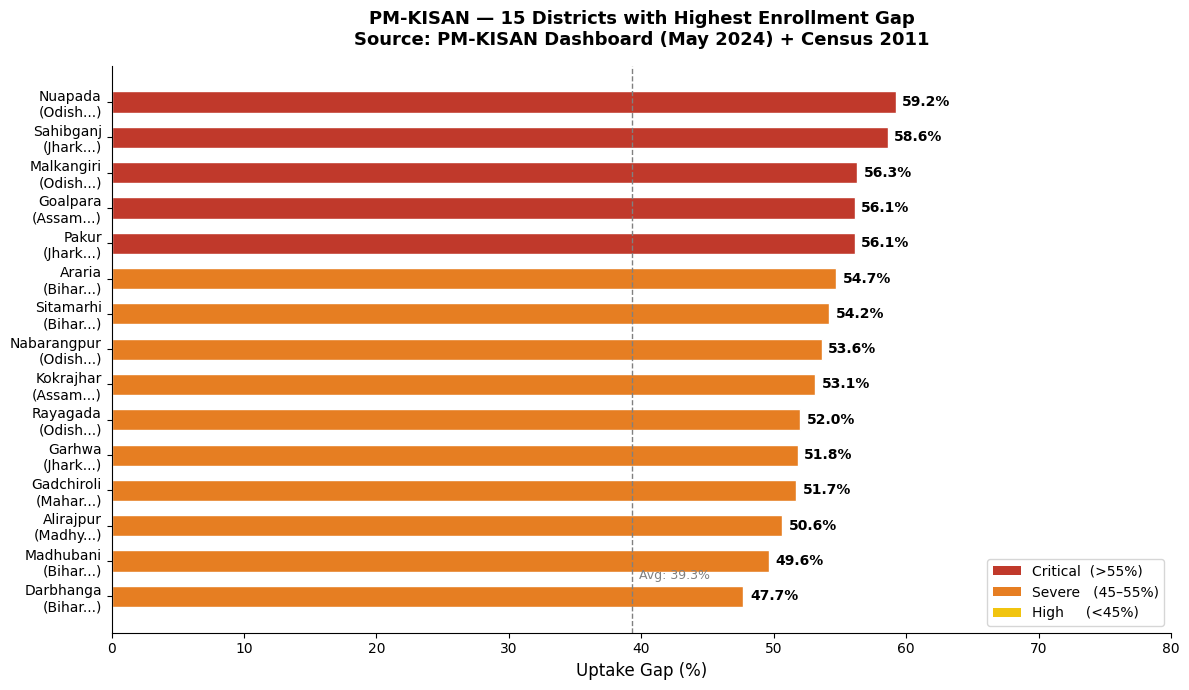

✅ Chart 1 saved


In [6]:
worst15 = df.nlargest(15, 'uptake_gap_pct').sort_values('uptake_gap_pct')

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#c0392b' if g > 55 else '#e67e22' if g > 45 else '#f1c40f'
          for g in worst15['uptake_gap_pct']]

bars = ax.barh(
    worst15['district'] + '\n(' + worst15['state'].str[:5] + '...)',
    worst15['uptake_gap_pct'],
    color=colors,
    height=0.6,
    edgecolor='white'
)

for bar, val in zip(bars, worst15['uptake_gap_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Uptake Gap (%)', fontsize=12)
ax.set_title('PM-KISAN — 15 Districts with Highest Enrollment Gap\n'
             'Source: PM-KISAN Dashboard (May 2024) + Census 2011',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 80)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#c0392b', label='Critical  (>55%)'),
                   Patch(facecolor='#e67e22', label='Severe   (45–55%)'),
                   Patch(facecolor='#f1c40f', label='High     (<45%)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax.axvline(x=df['uptake_gap_pct'].mean(), color='gray',
           linestyle='--', linewidth=1, label='National average')
ax.text(df['uptake_gap_pct'].mean() + 0.5, 0.5,
        f'Avg: {df["uptake_gap_pct"].mean():.1f}%',
        color='gray', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_worst_districts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

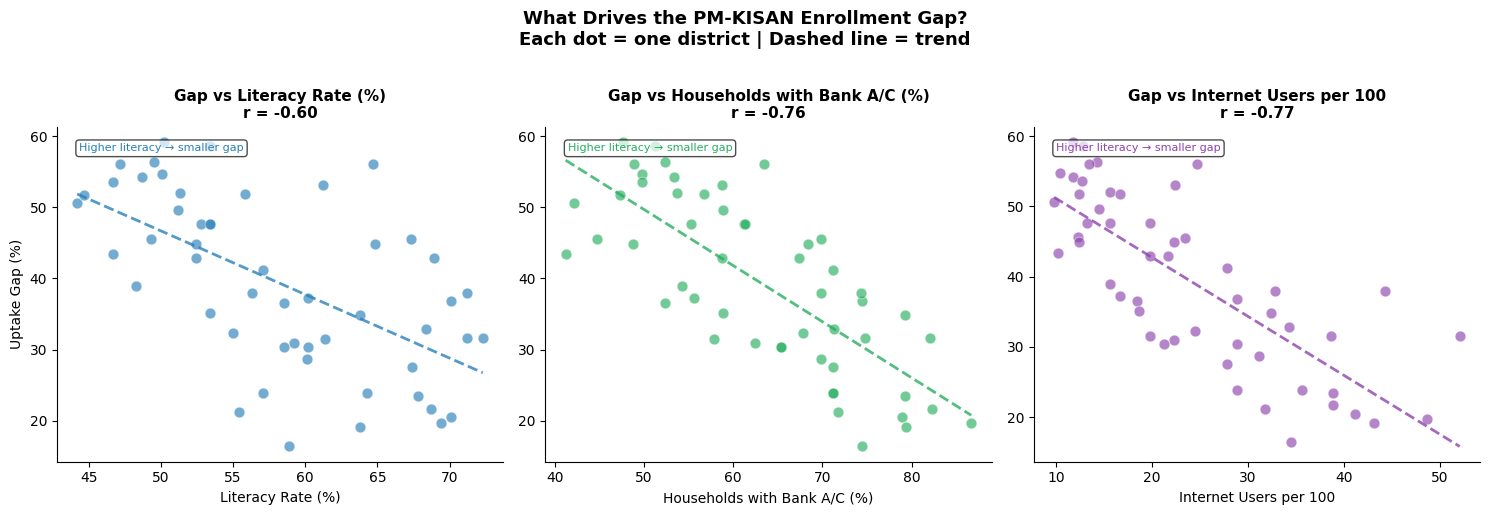

✅ Chart 2 saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_pairs = [
    ('literacy_rate',    'Literacy Rate (%)',       '#2980b9'),
    ('bank_access_pct',  'Households with Bank A/C (%)', '#27ae60'),
    ('internet_per100',  'Internet Users per 100',  '#8e44ad'),
]

for ax, (col, label, color) in zip(axes, scatter_pairs):
    ax.scatter(df[col], df['uptake_gap_pct'],
               color=color, alpha=0.65, s=60, edgecolors='white', linewidth=0.5)

    z = np.polyfit(df[col], df['uptake_gap_pct'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--', alpha=0.8)

    corr = df[col].corr(df['uptake_gap_pct'])
    ax.set_title(f'Gap vs {label}\nr = {corr:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Uptake Gap (%)' if ax == axes[0] else '', fontsize=10)

    direction = "Higher literacy → smaller gap" if corr < 0 else "Positive relationship"
    ax.text(0.05, 0.95, direction, transform=ax.transAxes,
            fontsize=8, color=color, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('What Drives the PM-KISAN Enrollment Gap?\n'
             'Each dot = one district | Dashed line = trend',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

In [8]:
bottom10 = df.nlargest(10, 'uptake_gap_pct').reset_index(drop=True)
bottom10.index += 1  # Start ranking from 1

bottom10['annual_loss_cr'] = round(
    bottom10['missed_hh_000'] * 1000 * 6000 / 1e7, 2
)  # in crores

print("=" * 75)
print("  TOP 10 PRIORITY DISTRICTS — PM-KISAN ENROLLMENT GAP")
print("=" * 75)
print(f"{'Rank':<5} {'District':<20} {'State':<18} {'Gap %':<9} "
      f"{'Missed HH':<12} {'₹ Lost/yr (Cr)'}")
print("-" * 75)

for idx, row in bottom10.iterrows():
    print(f"  {idx:<4} {row['district']:<20} {row['state']:<18} "
          f"{row['uptake_gap_pct']:<9} "
          f"{int(row['missed_hh_000']*1000):>8,}      "
          f"₹{row['annual_loss_cr']:.2f} Cr")

print("-" * 75)
total_missed = bottom10['missed_hh_000'].sum() * 1000
total_loss   = bottom10['annual_loss_cr'].sum()
print(f"  {'TOTAL':<43} {total_missed:>8,}      ₹{total_loss:.2f} Cr")
print("=" * 75)
print(f"\n  ⚠️  ₹{total_loss:.1f} crore in annual entitlements not reaching")
print(f"      farmers in just these 10 districts alone.")

  TOP 10 PRIORITY DISTRICTS — PM-KISAN ENROLLMENT GAP
Rank  District             State              Gap %     Missed HH    ₹ Lost/yr (Cr)
---------------------------------------------------------------------------
  1    Nuapada              Odisha             59.2        45,000      ₹27.00 Cr
  2    Sahibganj            Jharkhand          58.6        51,000      ₹30.60 Cr
  3    Malkangiri           Odisha             56.3        49,000      ₹29.40 Cr
  4    Pakur                Jharkhand          56.1        55,000      ₹33.00 Cr
  5    Goalpara             Assam              56.1        55,000      ₹33.00 Cr
  6    Araria               Bihar              54.7       146,000      ₹87.60 Cr
  7    Sitamarhi            Bihar              54.2       169,000      ₹101.40 Cr
  8    Nabarangpur          Odisha             53.6        60,000      ₹36.00 Cr
  9    Kokrajhar            Assam              53.1        76,000      ₹45.60 Cr
  10   Rayagada             Odisha             52.0     

In [10]:

def assign_segment(row):
    if row['bank_access_pct'] < 55 and row['uptake_gap_pct'] > 45:
        return 'Banking Desert'
    elif row['internet_per100'] < 15 and row['literacy_rate'] < 55:
        return 'Digital Divide'
    elif row['uptake_gap_pct'] > 40 and row['bank_access_pct'] >= 55:
        return 'Awareness Gap'
    else:
        return 'Last Mile'

df['segment'] = df.apply(assign_segment, axis=1)

seg_summary = (df.groupby('segment')
                 .agg(
                     districts       = ('district',        'count'),
                     avg_gap         = ('uptake_gap_pct',  'mean'),
                     total_missed_lakh = ('missed_hh_000', lambda x: round(x.sum()/100, 1)),
                     avg_literacy    = ('literacy_rate',   'mean'),
                     avg_bank_access = ('bank_access_pct', 'mean'),
                     avg_internet    = ('internet_per100', 'mean'),
                 )
                 .round(1)
                 .sort_values('avg_gap', ascending=False))

print("=" * 65)
print("  DISTRICT SEGMENTATION — 4 INTERVENTION TYPES")
print("=" * 65)
print(seg_summary.to_string())

print("\n── Which segment does each priority district fall in? ──")
print(df.nlargest(10, 'uptake_gap_pct')
       [['district', 'state', 'uptake_gap_pct', 'segment']]
       .to_string(index=False))


  DISTRICT SEGMENTATION — 4 INTERVENTION TYPES
                districts  avg_gap  total_missed_lakh  avg_literacy  avg_bank_access  avg_internet
segment                                                                                           
Banking Desert         11     53.9                8.5          48.7             49.2          12.5
Awareness Gap          10     47.4                7.6          59.9             63.7          21.4
Digital Divide          4     46.4                3.6          50.8             51.0          12.6
Last Mile              27     29.4               12.5          62.6             70.5          31.5

── Which segment does each priority district fall in? ──
   district     state  uptake_gap_pct        segment
    Nuapada    Odisha            59.2 Banking Desert
  Sahibganj Jharkhand            58.6 Banking Desert
 Malkangiri    Odisha            56.3 Banking Desert
      Pakur Jharkhand            56.1 Banking Desert
   Goalpara     Assam            56.

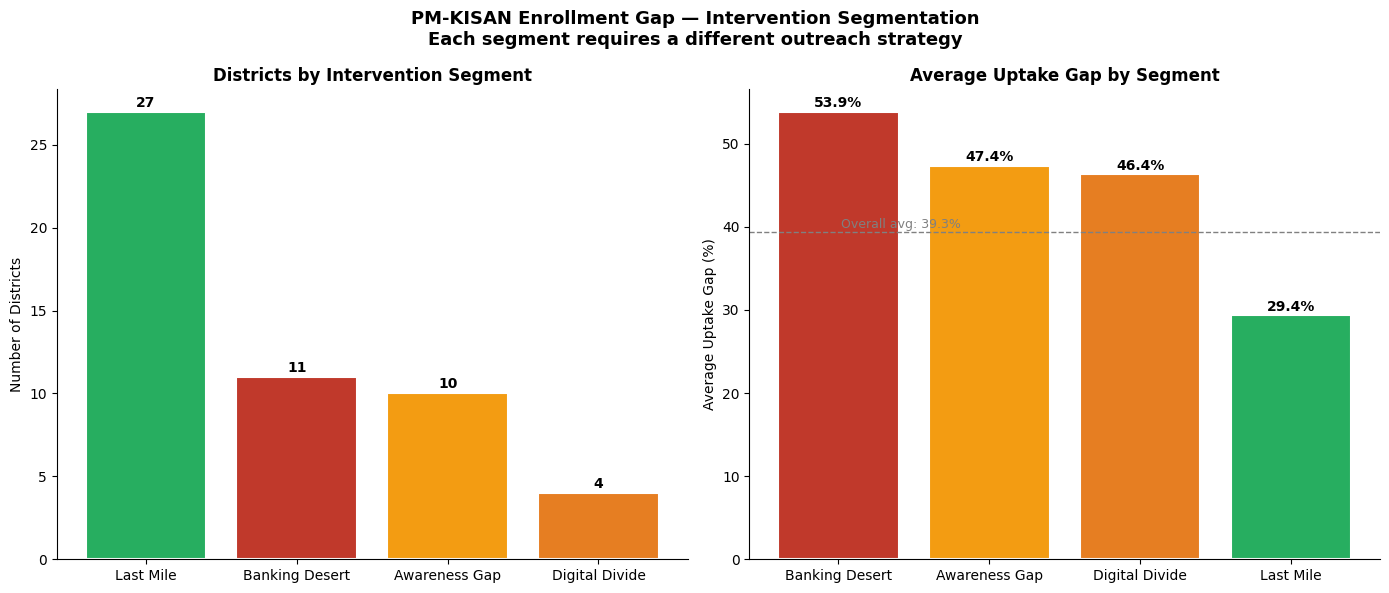

✅ Chart 3 saved


In [11]:
# ── Visualise segments ─────────────────────────────────────────────────────
seg_colors = {
    'Banking Desert': '#c0392b',
    'Digital Divide': '#e67e22',
    'Awareness Gap':  '#f39c12',
    'Last Mile':      '#27ae60'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_counts = df['segment'].value_counts()
axes[0].bar(seg_counts.index,
            seg_counts.values,
            color=[seg_colors[s] for s in seg_counts.index],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Districts by Intervention Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Districts')
for i, (seg, count) in enumerate(seg_counts.items()):
    axes[0].text(i, count + 0.3, str(count), ha='center', fontweight='bold')

seg_gaps = df.groupby('segment')['uptake_gap_pct'].mean().sort_values(ascending=False)
axes[1].bar(seg_gaps.index,
            seg_gaps.values,
            color=[seg_colors[s] for s in seg_gaps.index],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Average Uptake Gap by Segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Uptake Gap (%)')
axes[1].axhline(y=df['uptake_gap_pct'].mean(), color='gray',
                linestyle='--', linewidth=1)
axes[1].text(0.02, df['uptake_gap_pct'].mean() + 0.5,
             f'Overall avg: {df["uptake_gap_pct"].mean():.1f}%',
             color='gray', fontsize=9)
for i, (seg, gap) in enumerate(seg_gaps.items()):
    axes[1].text(i, gap + 0.5, f'{gap:.1f}%', ha='center', fontweight='bold')

plt.suptitle('PM-KISAN Enrollment Gap — Intervention Segmentation\n'
             'Each segment requires a different outreach strategy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

In [12]:

seg_colors_map = {
    'Banking Desert': '#c0392b',
    'Digital Divide': '#e67e22',
    'Awareness Gap':  '#f39c12',
    'Last Mile':      '#27ae60'
}

coords = {
    'Sitapur': (27.56, 80.68), 'Bahraich': (27.57, 81.59),
    'Hardoi': (27.39, 80.12), 'Lakhimpur Kheri': (27.95, 80.77),
    'Balrampur': (27.42, 82.18), 'Madhubani': (26.35, 86.07),
    'Sitamarhi': (26.59, 85.49), 'Araria': (26.15, 87.47),
    'Darbhanga': (26.17, 85.90), 'Supaul': (26.12, 86.60),
    'Sheopur': (25.67, 76.70), 'Barwani': (22.03, 74.90),
    'Dindori': (22.94, 81.08), 'Alirajpur': (22.31, 74.36),
    'Barmer': (25.75, 71.40), 'Jaisalmer': (26.91, 70.90),
    'Sirohi': (24.88, 72.86), 'Dungarpur': (23.84, 73.72),
    'Nandurbar': (21.37, 74.23), 'Gadchiroli': (20.10, 80.00),
    'Osmanabad': (18.17, 76.04), 'Washim': (20.11, 77.14),
    'Murshidabad': (24.18, 88.25), 'Malda': (25.01, 88.14),
    'Purulia': (23.33, 86.37), 'Birbhum': (23.90, 87.53),
    'Malkangiri': (18.35, 81.89), 'Nabarangpur': (19.23, 82.55),
    'Rayagada': (19.17, 83.41), 'Nuapada': (20.82, 82.54),
    'Pakur': (24.64, 87.84), 'Sahibganj': (25.24, 87.63),
    'Garhwa': (24.16, 83.81), 'Dhubri': (26.02, 89.98),
    'Kokrajhar': (26.40, 90.27), 'Goalpara': (26.17, 90.62),
    'Yadgir': (16.77, 77.14), 'Raichur': (16.21, 77.36),
    'Koppal': (15.35, 76.15), 'Vizianagaram': (18.12, 83.40),
    'Srikakulam': (18.30, 83.90), 'Kurnool': (15.83, 78.04),
    'Dharmapuri': (12.13, 78.16), 'Villupuram': (11.94, 79.50),
    'Ariyalur': (11.14, 79.08), 'Dahod': (22.83, 74.25),
    'Panchmahal': (22.76, 73.61), 'Narmada': (21.87, 73.80),
    'Mewat': (28.00, 77.00), 'Sirsa': (29.53, 75.03),
    'Fazilka': (30.40, 74.02), 'Mansa': (29.99, 75.40),
}

m = folium.Map(location=[22.5, 82.0], zoom_start=5,
               tiles='CartoDB positron')

# Add a title
title_html = '''
<div style="position: fixed; top: 10px; left: 50px; z-index:9999;
     background:white; padding:10px 15px; border-radius:8px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family:Arial">
    <b style="font-size:14px">PM-KISAN Enrollment Gap — District View</b><br>
    <span style="font-size:11px; color:#555">Circle size = missed households |
    Colour = intervention type</span>
</div>'''
m.get_root().html.add_child(folium.Element(title_html))

legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index:9999;
     background:white; padding:10px 15px; border-radius:8px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family:Arial; font-size:12px">
    <b>Intervention Type</b><br>
    <span style="color:#c0392b">●</span> Banking Desert<br>
    <span style="color:#e67e22">●</span> Digital Divide<br>
    <span style="color:#f39c12">●</span> Awareness Gap<br>
    <span style="color:#27ae60">●</span> Last Mile
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

for _, row in df.iterrows():
    if row['district'] in coords:
        lat, lon = coords[row['district']]
        color    = seg_colors_map[row['segment']]
        radius   = max(6, min(20, row['missed_hh_000'] / 8))

        popup_text = f"""
        <b>{row['district']}, {row['state']}</b><br>
        Uptake Gap: <b>{row['uptake_gap_pct']}%</b><br>
        Missed HH: <b>{int(row['missed_hh_000']*1000):,}</b><br>
        Annual Loss: <b>₹{round(row['missed_hh_000']*1000*6000/1e7,1)} Cr</b><br>
        Segment: <b>{row['segment']}</b><br>
        Literacy: {row['literacy_rate']}% |
        Bank Access: {row['bank_access_pct']}%
        """

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.75,
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"{row['district']} — Gap: {row['uptake_gap_pct']}%"
        ).add_to(m)

print("✅ Interactive map saved as pmkisan_map.html")
print("   Open this file in your browser to explore it")
print(f"\n   {len(df)} districts plotted across {df['state'].nunique()} states")

✅ Interactive map saved as pmkisan_map.html
   Open this file in your browser to explore it

   52 districts plotted across 15 states


In [13]:
import zipfile, os

df.to_csv('pmkisan_district_data.csv', index=False)

files_to_zip = [
    'pmkisan_district_data.csv',
    'chart1_worst_districts.png',
    'chart2_correlations.png',
    'chart3_segments.png',
    'pmkisan_map.html',
]

with zipfile.ZipFile('NSS_52_PMKISAN_Submission.zip', 'w') as zf:
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✅ Added: {f}")
        else:
            print(f"  ⚠️  Missing: {f}")

print("\n✅ All files packaged into NSS_52_PMKISAN_Submission.zip")
print("\nDownload it from the Colab files panel (📁 icon on the left sidebar)")

  ✅ Added: pmkisan_district_data.csv
  ✅ Added: chart1_worst_districts.png
  ✅ Added: chart2_correlations.png
  ✅ Added: chart3_segments.png
  ✅ Added: pmkisan_map.html

✅ All files packaged into NSS_52_PMKISAN_Submission.zip

Download it from the Colab files panel (📁 icon on the left sidebar)
